In [5]:
# ============================================================
# CELL 1: Import libraries
# ============================================================
import pandas as pd
import numpy as np
from dython.nominal import associations
from scipy.stats import chi2_contingency
import gc
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# ============================================================
# CELL 2: Define the complete function
# ============================================================
def compute_full_associations_memory_safe(df, chunk_size=10, output_file='./data/processed_data/correlation_matrix_full.csv'):
    """
    Compute COMPLETE correlation matrix in memory-safe chunks.
    Handles both within-chunk AND cross-chunk correlations.
    
    Args:
        df: DataFrame with mixed data types (40k rows x 36 columns)
        chunk_size: Columns per chunk (10-12 for 8-16GB RAM)
        output_file: CSV path to save results
    
    Returns:
        Full 36x36 correlation matrix (no missing pairs)
    """
    
    columns = df.columns.tolist()
    n_cols = len(columns)
    
    # Initialize full matrix
    full_corr = pd.DataFrame(np.nan, index=columns, columns=columns)
    np.fill_diagonal(full_corr.values, 1.0)  # Self-correlation = 1
    
    print(f"Computing {n_cols}x{n_cols} = {n_cols**2} associations...")
    print(f"Chunk size: {chunk_size} columns")
    
    # ============================================================
    # STEP 1: Diagonal blocks (within-chunk correlations)
    # ============================================================
    for i in range(0, n_cols, chunk_size):
        chunk_cols = columns[i:min(i+chunk_size, n_cols)]
        chunk_idx = i // chunk_size + 1
        total_chunks = (n_cols + chunk_size - 1) // chunk_size
        
        print(f"\n[{chunk_idx}/{total_chunks}] Processing diagonal chunk: {chunk_cols[0]} to {chunk_cols[-1]}")
        
        df_chunk = df[chunk_cols]
        chunk_corr = associations(df_chunk, compute_only=True)['corr']
        
        # Fill diagonal block
        full_corr.loc[chunk_cols, chunk_cols] = chunk_corr.values
        
        del df_chunk, chunk_corr
        gc.collect()
    
    # ============================================================
    # STEP 2: Off-diagonal blocks (cross-chunk correlations)
    # THIS IS THE KEY FIX - computes missing pairs!
    # ============================================================
    print("\n" + "="*70)
    print("Computing cross-chunk correlations (the missing 67%)...")
    print("="*70)
    
    total_cross_chunks = sum(1 for i in range(0, n_cols, chunk_size) 
                              for j in range(i + chunk_size, n_cols, chunk_size))
    processed = 0
    
    for i in range(0, n_cols, chunk_size):
        chunk_cols_i = columns[i:min(i+chunk_size, n_cols)]
        
        for j in range(i + chunk_size, n_cols, chunk_size):
            chunk_cols_j = columns[j:min(j+chunk_size, n_cols)]
            processed += 1
            
            print(f"[{processed}/{total_cross_chunks}] Cross-chunk: {chunk_cols_i[0]}...{chunk_cols_i[-1]} ↔ {chunk_cols_j[0]}...{chunk_cols_j[-1]}")
            
            # Combine columns for cross-correlation
            cross_cols = chunk_cols_i + chunk_cols_j
            df_cross = df[cross_cols]
            
            # Compute associations
            cross_corr = associations(df_cross, compute_only=True)['corr']
            
            # Extract relevant cross-correlation block
            cross_block = cross_corr.loc[chunk_cols_i, chunk_cols_j]
            
            # Fill both triangles (symmetric matrix)
            full_corr.loc[chunk_cols_i, chunk_cols_j] = cross_block.values
            full_corr.loc[chunk_cols_j, chunk_cols_i] = cross_block.T.values
            
            del df_cross, cross_corr, cross_block
            gc.collect()
    
    # ============================================================
    # STEP 3: Save and validate
    # ============================================================
    # Check for missing values
    missing_count = full_corr.isna().sum().sum()
    if missing_count > 0:
        print(f"\n⚠️ WARNING: {missing_count} missing correlations detected!")
    else:
        print("\n✅ SUCCESS: All correlations computed!")
    
    # Save results
    full_corr.to_csv(output_file)
    print(f"💾 Saved to: {output_file}")
    
    # Print summary stats
    print("\n" + "="*70)
    print("CORRELATION MATRIX SUMMARY")
    print("="*70)
    print(f"Shape: {full_corr.shape}")
    print(f"Total pairs: {n_cols * n_cols}")
    print(f"Non-diagonal pairs: {n_cols * (n_cols - 1) // 2}")
    print(f"Missing values: {missing_count}")
    
    return full_corr

In [8]:
# ============================================================
# CELL 3: Load data and run computation
# ============================================================
# Load your processed dataset
df = pd.read_csv("./data/processed_data/cybersecurity_attacks_processed_for_stats.csv")

print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

# Compute FULL correlation matrix (no missing pairs)
full_corr = compute_full_associations_memory_safe(
    df, 
    chunk_size=10,  # Adjust based on your RAM (8GB: 8, 16GB: 12, 32GB: 15)
    output_file='./data/processed_data/correlation_matrix_complete.csv'
)

Loaded dataset: 40,000 rows × 36 columns
Columns: ['Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source', 'Browser_family', 'OS_family', 'Device_brand', 'GeoLoc_City2', 'Device_type', 'isPrivate_Source', 'isPrivate_Destination', 'isPrivate_Proxy', 'ContinentName_Source', 'CountryName_Source', 'ContinentName_Destination', 'CountryName_Destination', 'ContinentName_Proxy', 'CountryName_Proxy', 'Source Port_Cat', 'Destination Port_Cat', 'Hours_div', 'GeoLoc_Country', 'GeoLoc_Country1', 'Packet_Length_Quartile', 'Day_Number', 'Is_Weekend', 'Anomaly Scores_Quartile']
Computing 36x36 = 1296 associations...
Chunk size: 10 columns

[1/4] Processing diagonal chunk: Protocol to Network Segment

[2/4] Processing diagonal chunk: Firewall Logs to isPrivate_Destination

[3/4] Processing diagonal chunk: isPrivate_Proxy to Hours_div

[4/4]

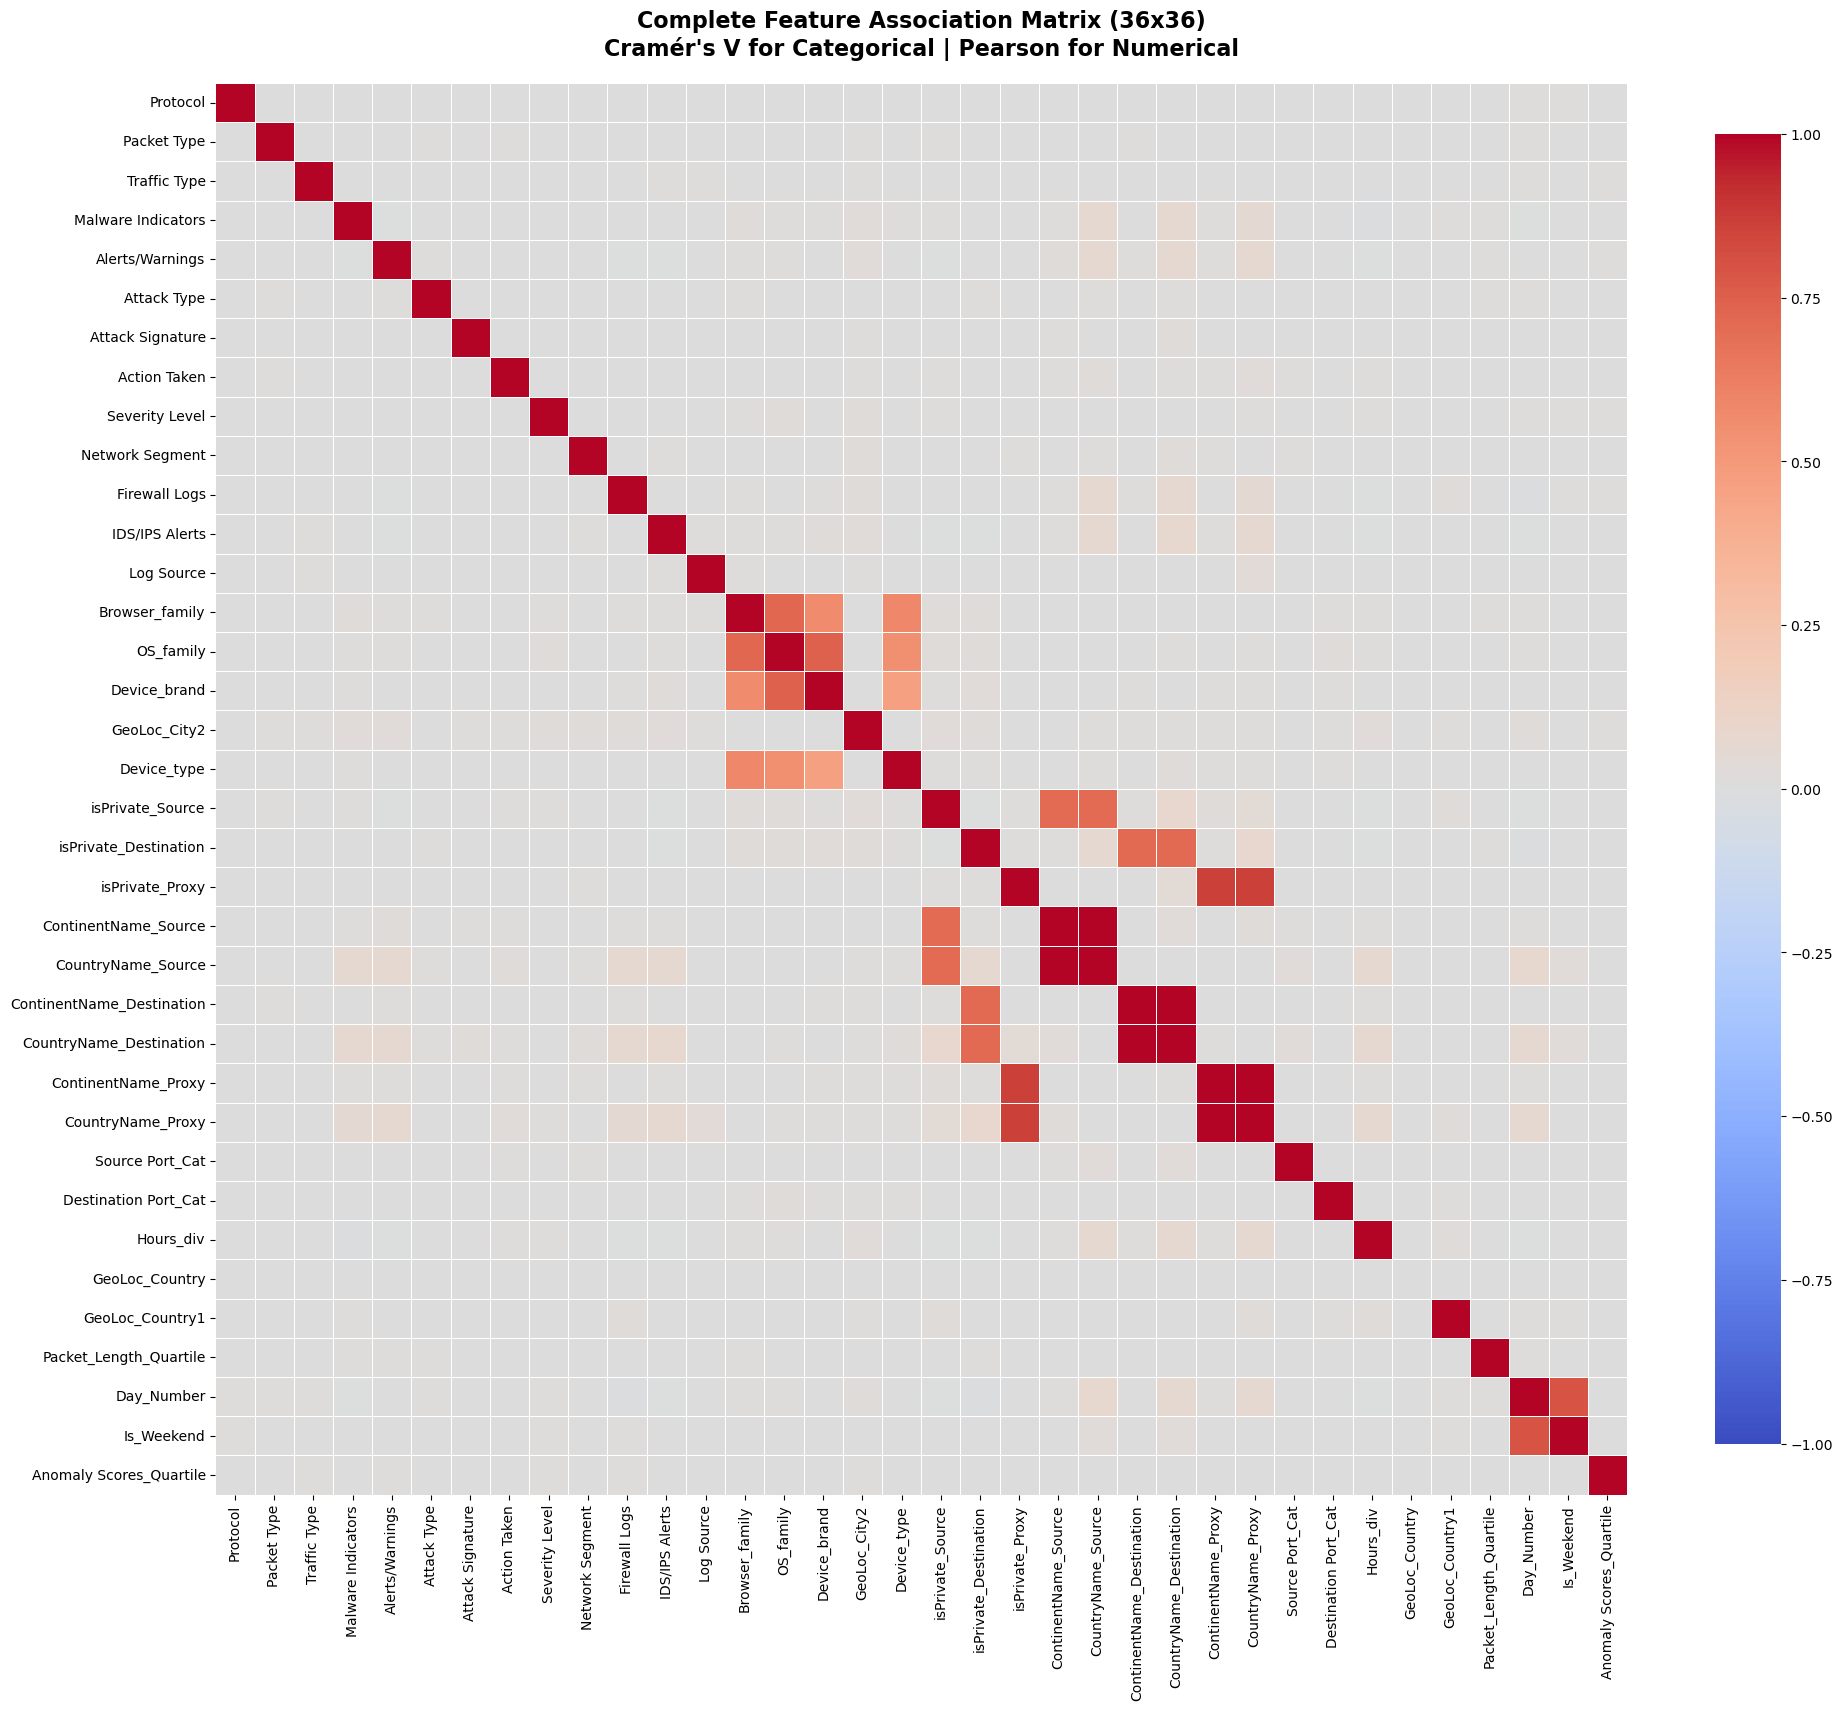

In [9]:
# ============================================================
# CELL 4: Visualization
# ============================================================
plt.figure(figsize=(20, 18))
sns.heatmap(full_corr, annot=False, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Complete Feature Association Matrix (36x36)\nCramér\'s V for Categorical | Pearson for Numerical', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('./data/processed_data/correlation_heatmap_complete.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# CELL 5: Find top correlations
# ============================================================
def get_top_correlations(corr_matrix, n=20):
    """Extract top N strongest correlations"""
    
    # Create a copy and remove diagonal
    corr_values = corr_matrix.values.copy()
    np.fill_diagonal(corr_values, np.nan)
    
    top_pairs = []
    for i in range(len(corr_matrix)):
        for j in range(i+1, len(corr_matrix)):
            if not np.isnan(corr_values[i, j]):
                top_pairs.append({
                    'Feature 1': corr_matrix.index[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_values[i, j],
                    'Abs_Correlation': abs(corr_values[i, j])
                })
    
    top_pairs_df = pd.DataFrame(top_pairs).sort_values('Abs_Correlation', ascending=False)
    return top_pairs_df.head(n)

# Display top correlations
print("\n" + "="*70)
print("TOP 20 STRONGEST ASSOCIATIONS")
print("="*70)
top_corr = get_top_correlations(full_corr, n=20)
print(top_corr[['Feature 1', 'Feature 2', 'Correlation']].to_string(index=False))


TOP 20 STRONGEST ASSOCIATIONS
                Feature 1                 Feature 2  Correlation
     ContinentName_Source        CountryName_Source     0.997760
ContinentName_Destination   CountryName_Destination     0.997324
      ContinentName_Proxy         CountryName_Proxy     0.997162
          isPrivate_Proxy       ContinentName_Proxy     0.867087
          isPrivate_Proxy         CountryName_Proxy     0.863085
               Day_Number                Is_Weekend     0.790214
                OS_family              Device_brand     0.746030
           Browser_family                 OS_family     0.724217
    isPrivate_Destination ContinentName_Destination     0.716012
    isPrivate_Destination   CountryName_Destination     0.713885
         isPrivate_Source        CountryName_Source     0.710466
         isPrivate_Source      ContinentName_Source     0.710466
           Browser_family               Device_type     0.584023
           Browser_family              Device_brand     0.5

In [16]:
# ============================================================
# CELL 6: Attack Type correlations
# ============================================================
if 'Attack Type' in full_corr.columns:
    attack_corr = full_corr['Attack Type'].drop('Attack Type').sort_values(ascending=False, key=abs)
    
    print("\n" + "="*70)
    print("FEATURES MOST CORRELATED WITH ATTACK TYPE")
    print("="*70)
    # Display with interpretation
    top_predictors = attack_corr.head(36)
    
    for feat, corr_val in top_predictors.items():
        strength = "🔴 Strong" if abs(corr_val) > 0.3 else \
                   "🟡 Moderate" if abs(corr_val) > 0.15 else \
                   "🟢 Weak"
        print(f"{feat:<35s} | {corr_val:>7.4f} | {strength}")
else:
    print("⚠️ 'Attack Type' column not found in correlation matrix")


FEATURES MOST CORRELATED WITH ATTACK TYPE
Browser_family                      |  0.0147 | 🟢 Weak
CountryName_Source                  |  0.0142 | 🟢 Weak
Alerts/Warnings                     |  0.0118 | 🟢 Weak
Packet Type                         |  0.0100 | 🟢 Weak
Packet_Length_Quartile              |  0.0100 | 🟢 Weak
CountryName_Destination             |  0.0089 | 🟢 Weak
isPrivate_Destination               |  0.0085 | 🟢 Weak
Day_Number                          |  0.0084 | 🟢 Weak
OS_family                           |  0.0075 | 🟢 Weak
Hours_div                           |  0.0065 | 🟢 Weak
Malware Indicators                  |  0.0064 | 🟢 Weak
Destination Port_Cat                |  0.0062 | 🟢 Weak
isPrivate_Source                    |  0.0055 | 🟢 Weak
Firewall Logs                       |  0.0040 | 🟢 Weak
Is_Weekend                          |  0.0040 | 🟢 Weak
IDS/IPS Alerts                      |  0.0036 | 🟢 Weak
Network Segment                     |  0.0026 | 🟢 Weak
Traffic Type          

In [15]:
# ============================================================
# CELL 8: Identify features to drop due to redundancy
# ============================================================

def identify_redundant_features(corr_matrix, threshold=0.95):
    """
    Find pairs of features that are TOO correlated (redundant).
    High correlation between features = BAD for model training!
    
    Args:
        corr_matrix: Full correlation matrix
        threshold: Correlation above this = redundant (default 0.95)
    
    Returns:
        List of features to DROP
    """
    
    # Get upper triangle (avoid duplicates)
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find pairs above threshold
    redundant_pairs = []
    for col in upper_tri.columns:
        high_corr = upper_tri[col][upper_tri[col] > threshold]
        for idx in high_corr.index:
            redundant_pairs.append({
                'Feature 1': idx,
                'Feature 2': col,
                'Correlation': corr_matrix.loc[idx, col],
                'Action': f'DROP one of them'
            })
    
    redundant_df = pd.DataFrame(redundant_pairs)
    
    if len(redundant_df) > 0:
        print("="*70)
        print(f"🔴 FOUND {len(redundant_df)} REDUNDANT FEATURE PAIRS")
        print("="*70)
        print(redundant_df.to_string(index=False))
        
        # Suggest features to drop (keep the first in each pair)
        features_to_drop = redundant_df['Feature 2'].unique().tolist()
        
        print("\n" + "="*70)
        print("📋 RECOMMENDED FEATURES TO DROP:")
        print("="*70)
        for i, feat in enumerate(features_to_drop, 1):
            print(f"{i}. {feat}")
        
        return features_to_drop
    else:
        print("✅ No redundant features found!")
        return []

# Run analysis
features_to_drop = identify_redundant_features(full_corr, threshold=0.95)

🔴 FOUND 3 REDUNDANT FEATURE PAIRS
                Feature 1               Feature 2  Correlation           Action
     ContinentName_Source      CountryName_Source     0.997760 DROP one of them
ContinentName_Destination CountryName_Destination     0.997324 DROP one of them
      ContinentName_Proxy       CountryName_Proxy     0.997162 DROP one of them

📋 RECOMMENDED FEATURES TO DROP:
1. CountryName_Source
2. CountryName_Destination
3. CountryName_Proxy


In [17]:
df.drop(columns=['CountryName_Source', 'CountryName_Destination', 'CountryName_Proxy'], inplace=True)

In [20]:
df.columns

Index(['Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators',
       'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken',
       'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts',
       'Log Source', 'Browser_family', 'OS_family', 'Device_brand',
       'GeoLoc_City2', 'Device_type', 'isPrivate_Source',
       'isPrivate_Destination', 'isPrivate_Proxy', 'ContinentName_Source',
       'ContinentName_Destination', 'ContinentName_Proxy', 'Source Port_Cat',
       'Destination Port_Cat', 'Hours_div', 'GeoLoc_Country',
       'GeoLoc_Country1', 'Packet_Length_Quartile', 'Day_Number', 'Is_Weekend',
       'Anomaly Scores_Quartile'],
      dtype='object')

🧩 How to Find Feature Combinations for Prediction

In [23]:
# ============================================================
# CELL 10: Feature interaction selection (CORRECTED)
# ============================================================

def prepare_features_for_ml(df, full_corr, target='Attack Type'):
    """
    Step-by-step feature selection for Attack Type prediction
    """
    
    print("="*70)
    print("FEATURE SELECTION PIPELINE FOR ML")
    print("="*70)
    
    # ============================================================
    # STEP 1: Remove redundant features (high feature-to-feature corr)
    # ============================================================
    print("\n📌 STEP 1: Remove Redundant Features")
    print("-"*70)
    
    redundant_features = [
        'ContinentName_Source',      # Keep CountryName_Source
        'ContinentName_Destination', # Keep CountryName_Destination
        'ContinentName_Proxy',       # Keep CountryName_Proxy
    ]
    
    print(f"Dropping {len(redundant_features)} redundant features:")
    for feat in redundant_features:
        print(f"  ❌ {feat}")
    
    # ============================================================
    # STEP 2: Keep features with ANY correlation to target
    # ============================================================
    print("\n📌 STEP 2: Identify Predictive Features")
    print("-"*70)
    
    if target in full_corr.columns:
        target_corr = full_corr[target].drop(target).abs()
        
        # Even weak correlations can be useful in combinations
        weak_predictors = target_corr[target_corr > 0.05].sort_values(ascending=False)
        
        print(f"Found {len(weak_predictors)} features with correlation > 0.05:")
        for feat, corr_val in weak_predictors.head(10).items():
            print(f"  ✓ {feat:<35s} | {corr_val:.4f}")
    
    # ============================================================
    # STEP 3: Feature engineering suggestions
    # ============================================================
    print("\n📌 STEP 3: Create Interaction Features")
    print("-"*70)
    print("Interactions defined by domain knowledge & correlation patterns:\n")
    
    # STRATEGY: Group interactions by cybersecurity domain
    interactions = []
    
    # ──────────────────────────────────────────────────────────
    # 1️⃣ NETWORK LAYER INTERACTIONS (Protocol + Traffic patterns)
    # ──────────────────────────────────────────────────────────
    print("1️⃣ NETWORK LAYER INTERACTIONS:")
    network_interactions = [
        ("Protocol", "Traffic Type", "Protocol_Traffic_Pattern"),
        ("Protocol", "Packet Type", "Protocol_Packet_Combo"),
        ("Packet Type", "Traffic Type", "Packet_Traffic_Type"),
        ("Source Port_Cat", "Destination Port_Cat", "Port_Direction_Flow"),
    ]
    interactions.extend(network_interactions)
    for feat1, feat2, name in network_interactions:
        print(f"   🔗 {feat1} × {feat2} → {name}")
        print(f"      Why: Network protocols behave differently with traffic types")
    
    # ──────────────────────────────────────────────────────────
    # 2️⃣ GEOGRAPHIC/NETWORK LOCALITY (IP-based features)
    # ──────────────────────────────────────────────────────────
    print("\n2️⃣ GEOGRAPHIC & NETWORK LOCALITY:")
    geo_interactions = [
        ("isPrivate_Source", "isPrivate_Destination", "Network_Locality_Type"),
        ("GeoLoc_Country", "GeoLoc_Country1", "Cross_Border_Traffic"),
        ("isPrivate_Source", "GeoLoc_Country", "Source_Network_Type"),
    ]
    interactions.extend(geo_interactions)
    for feat1, feat2, name in geo_interactions:
        print(f"   🔗 {feat1} × {feat2} → {name}")
        print(f"      Why: Internal vs external traffic patterns differ")
    
    # ──────────────────────────────────────────────────────────
    # 3️⃣ DEVICE FINGERPRINTING (OS, Browser, Device)
    # ──────────────────────────────────────────────────────────
    print("\n3️⃣ DEVICE FINGERPRINTING:")
    device_interactions = [
        ("OS_family", "Browser_family", "Device_Fingerprint"),
        ("OS_family", "Device_brand", "OS_Device_Combo"),
        ("Browser_family", "Device_type", "Browser_Device_Type"),
    ]
    interactions.extend(device_interactions)
    for feat1, feat2, name in device_interactions:
        print(f"   🔗 {feat1} × {feat2} → {name}")
        print(f"      Why: Attack patterns vary by device ecosystem (iOS/Safari vs Android/Chrome)")
    
    # ──────────────────────────────────────────────────────────
    # 4️⃣ TEMPORAL PATTERNS (Time-based features)
    # ──────────────────────────────────────────────────────────
    print("\n4️⃣ TEMPORAL ATTACK PATTERNS:")
    time_interactions = [
        ("Day_Number", "Hours_div", "Datetime_Pattern"),
        ("Is_Weekend", "Hours_div", "Weekend_Hour_Pattern"),
    ]
    interactions.extend(time_interactions)
    for feat1, feat2, name in time_interactions:
        print(f"   🔗 {feat1} × {feat2} → {name}")
        print(f"      Why: Attacks have temporal signatures (weekday office hours vs weekend)")
    
    # ──────────────────────────────────────────────────────────
    # 5️⃣ THREAT INTELLIGENCE (Security logs + indicators)
    # ──────────────────────────────────────────────────────────
    print("\n5️⃣ THREAT INTELLIGENCE SIGNALS:")
    threat_interactions = [
        ("Malware Indicators", "IDS/IPS Alerts", "Multi_Layer_Threat_Score"),
        ("Malware Indicators", "Alerts/Warnings", "Threat_Alert_Severity"),
        ("IDS/IPS Alerts", "Firewall Logs", "Security_Stack_Detection"),
        ("Severity Level", "Attack Signature", "Attack_Severity_Profile"),
    ]
    interactions.extend(threat_interactions)
    for feat1, feat2, name in threat_interactions:
        print(f"   🔗 {feat1} × {feat2} → {name}")
        print(f"      Why: Multiple security signals together indicate attack confidence")
    
    # ──────────────────────────────────────────────────────────
    # 6️⃣ BEHAVIORAL ANOMALIES (Packet size + anomaly scores)
    # ──────────────────────────────────────────────────────────
    print("\n6️⃣ BEHAVIORAL ANOMALY PATTERNS:")
    anomaly_interactions = [
        ("Packet_Length_Quartile", "Anomaly Scores_Quartile", "Size_Anomaly_Profile"),
        ("Traffic Type", "Anomaly Scores_Quartile", "Traffic_Anomaly_Score"),
    ]
    interactions.extend(anomaly_interactions)
    for feat1, feat2, name in anomaly_interactions:
        print(f"   🔗 {feat1} × {feat2} → {name}")
        print(f"      Why: Unusual packet sizes + high anomaly scores = suspicious activity")
    
    # ──────────────────────────────────────────────────────────
    # 7️⃣ LOG SOURCE CONTEXT (Where the detection came from)
    # ──────────────────────────────────────────────────────────
    print("\n7️⃣ LOG SOURCE CONTEXT:")
    log_interactions = [
        ("Log Source", "Network Segment", "Detection_Location"),
        ("Log Source", "Action Taken", "Response_Source_Type"),
    ]
    interactions.extend(log_interactions)
    for feat1, feat2, name in log_interactions:
        print(f"   🔗 {feat1} × {feat2} → {name}")
        print(f"      Why: Different log sources have different reliability/context")
    
    # ──────────────────────────────────────────────────────────
    # SUMMARY
    # ──────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print(f"📊 TOTAL INTERACTION FEATURES: {len(interactions)}")
    print("="*70)
    
    # ============================================================
    # STEP 4: Final feature set recommendation
    # ============================================================
    print("\n📌 STEP 4: Final Feature Set")
    print("-"*70)
    
    all_features = df.columns.tolist()
    features_to_keep = [f for f in all_features if f not in redundant_features and f != target]
    
    print(f"Original features: {len(features_to_keep)}")
    print(f"Potential new interaction features: {len(interactions)}")
    print(f"Total features after engineering: {len(features_to_keep) + len(interactions)}")
    print(f"Dropped redundant features: {len(redundant_features)}")
    print(f"Target variable: {target}")
    
    return features_to_keep, redundant_features, interactions

# Run feature selection
X_features, dropped_features, interaction_features = prepare_features_for_ml(df, full_corr, target='Attack Type')

FEATURE SELECTION PIPELINE FOR ML

📌 STEP 1: Remove Redundant Features
----------------------------------------------------------------------
Dropping 3 redundant features:
  ❌ ContinentName_Source
  ❌ ContinentName_Destination
  ❌ ContinentName_Proxy

📌 STEP 2: Identify Predictive Features
----------------------------------------------------------------------
Found 0 features with correlation > 0.05:

📌 STEP 3: Create Interaction Features
----------------------------------------------------------------------
Interactions defined by domain knowledge & correlation patterns:

1️⃣ NETWORK LAYER INTERACTIONS:
   🔗 Protocol × Traffic Type → Protocol_Traffic_Pattern
      Why: Network protocols behave differently with traffic types
   🔗 Protocol × Packet Type → Protocol_Packet_Combo
      Why: Network protocols behave differently with traffic types
   🔗 Packet Type × Traffic Type → Packet_Traffic_Type
      Why: Network protocols behave differently with traffic types
   🔗 Source Port_Cat × D

In [24]:
# ============================================================
# CELL 11: Automated interaction suggestion
# ============================================================

def suggest_interactions_from_correlation(full_corr, target='Attack Type', 
                                          min_corr=0.5, max_corr=0.95):
    """
    Automatically suggest feature interactions based on correlation matrix
    
    Args:
        full_corr: Full correlation matrix
        target: Target variable to exclude
        min_corr: Minimum correlation to consider (0.5 = moderate)
        max_corr: Maximum correlation to avoid (0.95 = too redundant)
    
    Returns:
        List of suggested interaction tuples
    """
    
    print("="*70)
    print("AUTOMATED INTERACTION SUGGESTIONS")
    print("="*70)
    print(f"Looking for feature pairs with {min_corr} < correlation < {max_corr}\n")
    
    # Get upper triangle (avoid duplicates)
    upper_tri = full_corr.where(
        np.triu(np.ones(full_corr.shape), k=1).astype(bool)
    )
    
    suggested_interactions = []
    
    for col in upper_tri.columns:
        if col == target:
            continue
            
        # Find moderately correlated features
        moderate_corr = upper_tri[col][(upper_tri[col] > min_corr) & 
                                        (upper_tri[col] < max_corr)]
        
        for idx in moderate_corr.index:
            if idx == target:
                continue
            
            interaction_name = f"{idx}_{col}_Interaction"
            corr_value = full_corr.loc[idx, col]
            
            suggested_interactions.append({
                'Feature 1': idx,
                'Feature 2': col,
                'Correlation': corr_value,
                'Interaction Name': interaction_name,
                'Reasoning': f"Moderate correlation ({corr_value:.3f}) suggests complementary info"
            })
    
    # Sort by correlation strength
    suggestions_df = pd.DataFrame(suggested_interactions).sort_values('Correlation', ascending=False)
    
    print(f"Found {len(suggestions_df)} potential interactions:\n")
    print(suggestions_df.to_string(index=False))
    
    return suggestions_df

# Run automated suggestion
auto_interactions = suggest_interactions_from_correlation(
    full_corr, 
    target='Attack Type',
    min_corr=0.5,   # Moderate correlation
    max_corr=0.95   # Not too redundant
)

AUTOMATED INTERACTION SUGGESTIONS
Looking for feature pairs with 0.5 < correlation < 0.95

Found 12 potential interactions:

            Feature 1                 Feature 2  Correlation                                            Interaction Name                                                Reasoning
      isPrivate_Proxy       ContinentName_Proxy     0.867087             isPrivate_Proxy_ContinentName_Proxy_Interaction Moderate correlation (0.867) suggests complementary info
      isPrivate_Proxy         CountryName_Proxy     0.863085               isPrivate_Proxy_CountryName_Proxy_Interaction Moderate correlation (0.863) suggests complementary info
           Day_Number                Is_Weekend     0.790214                           Day_Number_Is_Weekend_Interaction Moderate correlation (0.790) suggests complementary info
            OS_family              Device_brand     0.746030                          OS_family_Device_brand_Interaction Moderate correlation (0.746) suggests comp